# Resource 3: E-commerce Customer Statistics

This notebook answers all ten client questions using descriptive statistics, probability, correlation, a z-score, and a confidence interval. Each section shows the calculation and a plain-language interpretation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
DATA_PATH = Path('data/ecommerce_data.csv')
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')


Rows: 1,000 | Columns: 7


## Data-quality check

In [2]:
quality = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique()
})
display(quality)
print(f'Duplicate rows: {df.duplicated().sum()}')

,data_type,missing_values,unique_values
cust_id,str,0,1000
gender,str,0,2
age,int64,0,48
no_of_purchases,int64,0,8
amount_spend,int64,0,38
time_spent_on_site,float64,0,925
cross_sell_conversion_rate,float64,0,1000


Duplicate rows: 0


## 1. Range of customer age
Range = maximum age - minimum age.

In [3]:
minimum_age = df['age'].min()
maximum_age = df['age'].max()
age_range = maximum_age - minimum_age
print(f'Minimum age: {minimum_age}')
print(f'Maximum age: {maximum_age}')
print(f'Answer - age range: {age_range} years')

Minimum age: 18
Maximum age: 65
Answer - age range: 47 years


## 2. Mean, median, and mode of amount spent

In [4]:
spend_mean = df['amount_spend'].mean()
spend_median = df['amount_spend'].median()
spend_modes = df['amount_spend'].mode().tolist()
print(f'Answer - mean: {spend_mean:.2f}')
print(f'Answer - median: {spend_median:.2f}')
print(f'Answer - mode: {spend_modes}')

Answer - mean: 238.23
Answer - median: 200.00
Answer - mode: [240]


## 3. Variance and standard deviation of time spent on site
Pandas uses sample variance and sample standard deviation by default (`ddof=1`). Population values are also shown for transparency.

In [5]:
time_variance_sample = df['time_spent_on_site'].var(ddof=1)
time_std_sample = df['time_spent_on_site'].std(ddof=1)
time_variance_population = df['time_spent_on_site'].var(ddof=0)
time_std_population = df['time_spent_on_site'].std(ddof=0)
print(f'Answer - sample variance: {time_variance_sample:.2f}')
print(f'Answer - sample standard deviation: {time_std_sample:.2f}')
print(f'Population variance: {time_variance_population:.2f}')
print(f'Population standard deviation: {time_std_population:.2f}')

Answer - sample variance: 277.78
Answer - sample standard deviation: 16.67
Population variance: 277.50
Population standard deviation: 16.66


## 4. Interquartile range of amount spent
IQR = third quartile (Q3) - first quartile (Q1).

In [6]:
q1 = df['amount_spend'].quantile(0.25)
q3 = df['amount_spend'].quantile(0.75)
spend_iqr = q3 - q1
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'Answer - IQR: {spend_iqr:.2f}')

Q1: 120.00
Q3: 320.00
Answer - IQR: 200.00


## 5. Relationship between purchases and time spent on site
Pearson correlation measures the direction and strength of the linear relationship.

Answer - Pearson correlation: 0.9376
Interpretation: This is a very strong positive relationship. Customers who make more purchases generally spend more time on the site.


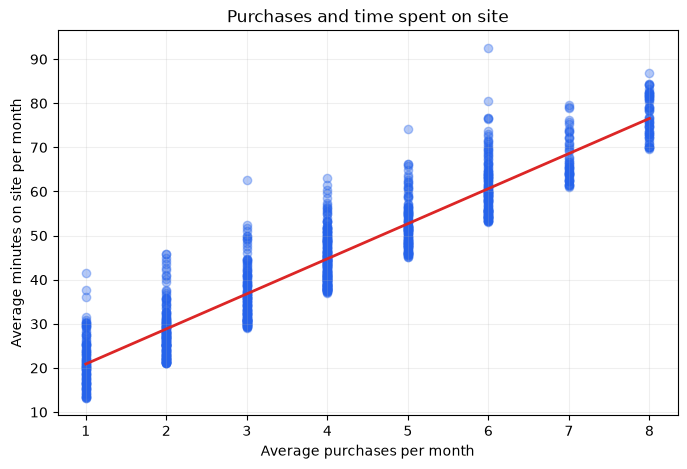

In [7]:
purchase_time_correlation = df['no_of_purchases'].corr(df['time_spent_on_site'])
print(f'Answer - Pearson correlation: {purchase_time_correlation:.4f}')
print('Interpretation: This is a very strong positive relationship. Customers who make more purchases generally spend more time on the site.')

plt.figure(figsize=(8, 5))
plt.scatter(df['no_of_purchases'], df['time_spent_on_site'], alpha=0.35, color='#2563eb')
trend = np.polyfit(df['no_of_purchases'], df['time_spent_on_site'], 1)
x_values = np.array(sorted(df['no_of_purchases'].unique()))
plt.plot(x_values, trend[0] * x_values + trend[1], color='#dc2626', linewidth=2)
plt.title('Purchases and time spent on site')
plt.xlabel('Average purchases per month')
plt.ylabel('Average minutes on site per month')
plt.grid(alpha=0.2)
plt.show()

## 6. Z-score for an amount spent of 450
The supplied formula is `z = (x - population mean) / population standard deviation`, so this calculation uses `ddof=0`.

In [8]:
x = 450
population_mean = df['amount_spend'].mean()
population_std = df['amount_spend'].std(ddof=0)
z_score = (x - population_mean) / population_std
print(f'Population mean: {population_mean:.2f}')
print(f'Population standard deviation: {population_std:.2f}')
print(f'Answer - z-score for 450: {z_score:.2f}')
print('Interpretation: 450 is about 1.36 standard deviations above the mean.')

Population mean: 238.23
Population standard deviation: 155.86
Answer - z-score for 450: 1.36
Interpretation: 450 is about 1.36 standard deviations above the mean.


## 7. Skewness of amount spent

Answer - skewness: 0.9581
Answer - direction: right-skewed (positive skew)


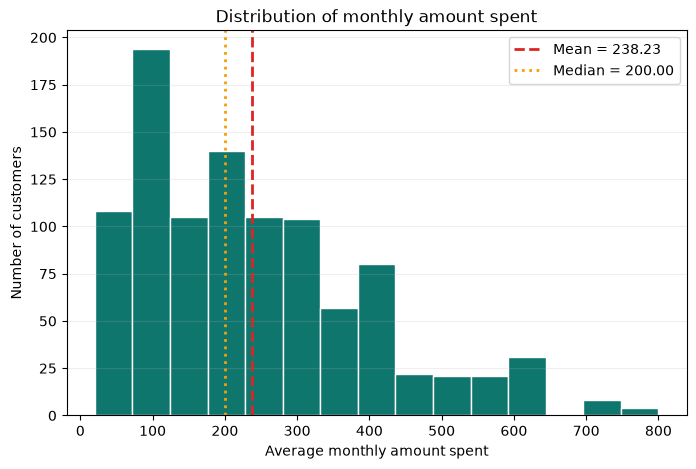

In [9]:
spend_skewness = df['amount_spend'].skew()
direction = 'right-skewed (positive skew)' if spend_skewness > 0 else 'left-skewed (negative skew)' if spend_skewness < 0 else 'approximately symmetric'
print(f'Answer - skewness: {spend_skewness:.4f}')
print(f'Answer - direction: {direction}')

plt.figure(figsize=(8, 5))
plt.hist(df['amount_spend'], bins=15, color='#0f766e', edgecolor='white')
plt.axvline(spend_mean, color='#dc2626', linestyle='--', linewidth=2, label=f'Mean = {spend_mean:.2f}')
plt.axvline(spend_median, color='#f59e0b', linestyle=':', linewidth=2, label=f'Median = {spend_median:.2f}')
plt.title('Distribution of monthly amount spent')
plt.xlabel('Average monthly amount spent')
plt.ylabel('Number of customers')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

## 8. Probability of more than 5 purchases OR spending more than 300
Using the addition rule: `P(A or B) = P(A) + P(B) - P(A and B)`. The intersection is subtracted to avoid double-counting customers who meet both conditions.

In [10]:
event_a = df['no_of_purchases'] > 5
event_b = df['amount_spend'] > 300
p_a = event_a.mean()
p_b = event_b.mean()
p_intersection = (event_a & event_b).mean()
p_union = p_a + p_b - p_intersection
print(f'P(more than 5 purchases): {p_a:.3f}')
print(f'P(spends more than 300): {p_b:.3f}')
print(f'P(both): {p_intersection:.3f}')
print(f'Answer - P(A or B): {p_union:.3f} ({p_union:.1%})')

P(more than 5 purchases): 0.255
P(spends more than 300): 0.280
P(both): 0.139
Answer - P(A or B): 0.396 (39.6%)


## 9. 95% confidence interval for mean amount spent
Using the requested z critical value of 1.96 and the sample standard deviation: `mean ± 1.96 × s / sqrt(n)`. The sample is large (`n = 1,000`), so the z-based interval is appropriate for this task.

In [11]:
n = df['amount_spend'].count()
sample_mean = df['amount_spend'].mean()
sample_std = df['amount_spend'].std(ddof=1)
z_critical = 1.96
standard_error = sample_std / np.sqrt(n)
margin_of_error = z_critical * standard_error
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print(f'Sample mean: {sample_mean:.2f}')
print(f'Margin of error: {margin_of_error:.2f}')
print(f'Answer - 95% confidence interval: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})')

Sample mean: 238.23
Margin of error: 9.67
Answer - 95% confidence interval: (228.56, 247.90)


## 10. Conditional probability of conversion rate above 80% given at least 5 purchases
`P(rate > 0.80 | purchases >= 5) = count(both conditions) / count(purchases >= 5)`. Note that the condition here is *at least 5*, unlike Question 8, which says *more than 5*.

In [12]:
purchase_condition = df['no_of_purchases'] >= 5
conversion_condition = df['cross_sell_conversion_rate'] > 0.80
condition_count = purchase_condition.sum()
joint_count = (purchase_condition & conversion_condition).sum()
conditional_probability = joint_count / condition_count
print(f'Customers with at least 5 purchases: {condition_count}')
print(f'Customers meeting both conditions: {joint_count}')
print(f'Answer - conditional probability: {conditional_probability:.4f} ({conditional_probability:.2%})')

Customers with at least 5 purchases: 385
Customers meeting both conditions: 135
Answer - conditional probability: 0.3506 (35.06%)


## Final answer summary

In [13]:
answers = pd.DataFrame({
    'Question': range(1, 11),
    'Result': [
        f'{age_range} years',
        f'Mean {spend_mean:.2f}, median {spend_median:.2f}, mode {spend_modes[0]}',
        f'Sample variance {time_variance_sample:.2f}, sample SD {time_std_sample:.2f}',
        f'{spend_iqr:.2f}',
        f'{purchase_time_correlation:.4f}, very strong positive relationship',
        f'{z_score:.2f}',
        f'{spend_skewness:.4f}, right-skewed',
        f'{p_union:.3f} ({p_union:.1%})',
        f'({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})',
        f'{conditional_probability:.4f} ({conditional_probability:.2%})'
    ]
})
answers.style.hide(axis='index')

Question,Result
1,47 years
2,"Mean 238.23, median 200.00, mode 240"
3,"Sample variance 277.78, sample SD 16.67"
4,200.00
5,"0.9376, very strong positive relationship"
6,1.36
7,"0.9581, right-skewed"
8,0.396 (39.6%)
9,"(228.56, 247.90)"
10,0.3506 (35.06%)
